# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Fatima-05/FlyRank-ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

Research question:
Given page-level search and content signals, which pages should a small team refresh first?

Decision supported:
Build a short ranked refresh queue so a reviewer can decide what to touch next, instead of scanning everything by hand.

This is decision-support ranking, not a claim about Google's algorithm or causal traffic lift after a refresh.

In [10]:
import os
from pathlib import Path

# Clone only if needed
if not Path("/content/FlyRank-ML").exists():
    !git clone https://github.com/Fatima-05/FlyRank-ML.git /content/FlyRank-ML

os.chdir("/content/FlyRank-ML")
print("CWD:", Path.cwd())
print("CSV exists:", Path("data/raw/content_refresh_anonymized.csv").exists())

CWD: /content/FlyRank-ML
CSV exists: True


## 2. Data

Release: FlyRank ML Internship warehouse (Hugging Face), plus the starter page-level table used in early notebooks.

Unit of analysis: one content item (page) after aggregation.

Early reproducible slice: data/raw/content_refresh_anonymized.csv (~30,000 rows).

Full warehouse access pattern (later work): DuckDB over hf://datasets/FlyRank/internship-warehouse.

Date practice: develop on mid-panel months; treat the final month as sealed.

Excluded from all public outputs:
- client names
- domains / URLs
- private queries
- credentials
- raw private exports

In [11]:
from pathlib import Path
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print("Rows:", len(df))
print("Columns sample:", df.columns.tolist()[:12])
df.head(2)

Rows: 30000
Columns sample: ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used']


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7


## 3. Methodology

Task type: ranking/opportunity scoring.

Proxy label:
is_declining = 1 when trend_direction is down.
This is an evaluation proxy, not confirmed editorial ground truth.

Baseline:
Hand-written rule using decline, visibility, aging, and weak-CTR style cues.

Model:
Random forest (decision tree shown as a middle reference).

Metric:
Precision@50 = share of top-50 ranked pages that match the proxy label.
Chosen because a small team can only work a short list.

Validation:
Client-holdout style split (GroupShuffleSplit on client_id when available).
Same split for baseline and models.

Leakage:
No future-window targets and no pure label copies in features.
Earlier trap notebooks documented the leakage lesson; final features stay decision-time only.

In [12]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

df = df.copy()
df["is_declining"] = (df["trend_direction"].astype(str).str.lower() == "down").astype(int)

feature_cols = [c for c in [
    "impressions_90d", "clicks_90d", "ctr", "content_age_days",
    "word_count", "avg_position", "search_volume"
] if c in df.columns]

X = df[feature_cols].fillna(0)
y = df["is_declining"]
groups = df["client_id"] if "client_id" in df.columns else pd.Series(np.arange(len(df)))

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

print("Features:", feature_cols)
print("Train:", len(X_tr), "Test:", len(X_te), "Test declining rate:", round(y_te.mean(), 3))

Features: ['impressions_90d', 'clicks_90d', 'ctr', 'content_age_days', 'word_count', 'avg_position', 'search_volume']
Train: 22885 Test: 7115 Test declining rate: 0.517


## 4. Results (vs baseline)


Same held-out split for every method.
Numbers below are measured Precision@50 on the proxy label.

In [13]:
def baseline_score(row):
    """Hand-written rule using only non-label signals."""
    score = 0
    imp = row.get("impressions_90d", 0) or 0
    age = row.get("content_age_days", 0) or 0
    ctr = row.get("ctr", None)
    pos = row.get("avg_position", None)
    words = row.get("word_count", 0) or 0

    # visibility / demand
    if imp >= 5000:
        score += 30
    elif imp >= 2000:
        score += 20
    elif imp >= 500:
        score += 10

    # aging content
    if age >= 365:
        score += 25
    elif age >= 180:
        score += 15
    elif age >= 90:
        score += 5

    # weak CTR on visible pages
    if ctr is not None and imp >= 500:
        if ctr < 0.01:
            score += 20
        elif ctr < 0.02:
            score += 10

    # striking-distance-ish position
    if pos is not None:
        if 4 <= pos <= 15:
            score += 15
        elif 15 < pos <= 30:
            score += 5

    # thin content flag
    if words > 0 and words < 400:
        score += 5

    return score

def precision_at_k(frame, score_col, k=50):
    top = frame.sort_values(score_col, ascending=False).head(k)
    return float(top["is_declining"].mean())

test = df.iloc[test_idx].copy()
test["baseline_score"] = test.apply(baseline_score, axis=1)

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
rf.fit(X_tr, y_tr)
dt.fit(X_tr, y_tr)

test["rf_score"] = rf.predict_proba(X_te)[:, 1]
test["dt_score"] = dt.predict_proba(X_te)[:, 1]

p_base = precision_at_k(test, "baseline_score")
p_dt = precision_at_k(test, "dt_score")
p_rf = precision_at_k(test, "rf_score")

results = pd.DataFrame({
    "model": ["baseline_rules", "decision_tree", "random_forest"],
    "precision_at_50": [p_base, p_dt, p_rf],
})
print(results)
print(f"RF / baseline: {p_rf / max(p_base, 1e-9):.2f}x")
results

            model  precision_at_50
0  baseline_rules             0.50
1   decision_tree             0.42
2   random_forest             0.62
RF / baseline: 1.24x


,model,precision_at_50
0,baseline_rules,0.50
1,decision_tree,0.42
2,random_forest,0.62


## 5. Limitations

What this work cannot claim:
- Causal proof that refreshing a flagged page improves rankings or traffic
- That the proxy label equals real editorial judgment
- Live team adoption or measured business impact
- Anything about a search engine's ranking algorithm

What it does support:
- An offline comparison of ranking methods on the same client-holdout split
- A directional decision-support queue for human review

Measured result on this run:
baseline_rules 0.50 | decision_tree 0.42 | random_forest 0.62 Precision@50

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [14]:
def reason_code(row):
    reasons = []
    if (row.get("impressions_90d", 0) or 0) >= 2000:
        reasons.append("high_impressions")
    if (row.get("ctr", 1) or 1) < 0.02:
        reasons.append("low_ctr")
    if (row.get("content_age_days", 0) or 0) >= 180:
        reasons.append("aging")
    pos = row.get("avg_position", None)
    if pos is not None and 4 <= pos <= 15:
        reasons.append("striking_distance")
    return ",".join(reasons) if reasons else "review"

queue = test.sort_values("rf_score", ascending=False).head(10).copy()
queue["action"] = np.where(queue["rf_score"] >= queue["rf_score"].median(), "refresh", "monitor")
queue["reason_code"] = queue.apply(reason_code, axis=1)

show_cols = [c for c in [
    "content_id", "rf_score", "action", "reason_code",
    "impressions_90d", "ctr", "avg_position", "content_age_days"
] if c in queue.columns]

queue[show_cols]

,content_id,rf_score,action,reason_code,impressions_90d,ctr,avg_position,content_age_days
12651,content_2a228ce7aa1b,0.827218,refresh,striking_distance,155,0.0,7.5,174
21729,content_7766ffacdcfa,0.823919,refresh,"aging,striking_distance",657,0.0,9.3,275
6228,content_e988c1699454,0.823176,refresh,"high_impressions,aging",2197,0.0,21.5,275
12591,content_7e24f3b27d73,0.822540,refresh,"aging,striking_distance",825,0.0,11.6,275
15705,content_4dd569ee33c9,0.820898,refresh,"aging,striking_distance",361,0.0,14.8,275
18475,content_197a5b1ed096,0.820840,monitor,"aging,striking_distance",605,0.0,14.4,223
22042,content_2ba626fea4d6,0.820807,monitor,"aging,striking_distance",360,0.0,7.2,275
22730,content_bb1edbf0ba6c,0.820412,monitor,"aging,striking_distance",1290,0.0,12.4,280
28718,content_ef6e7d7cfe15,0.818753,monitor,aging,264,0.0,22.2,271
20736,content_41baf0722ad9,0.818490,monitor,"high_impressions,aging,striking_distance",3115,0.0,12.8,275


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Wrote work/outputs/capstone_precision_at_50.csv
Wrote work/outputs/capstone_top10_queue.csv
Wrote work/outputs/capstone_precision_at_50.png


,model,precision_at_50
0,baseline_rules,0.50
1,decision_tree,0.42
2,random_forest,0.62


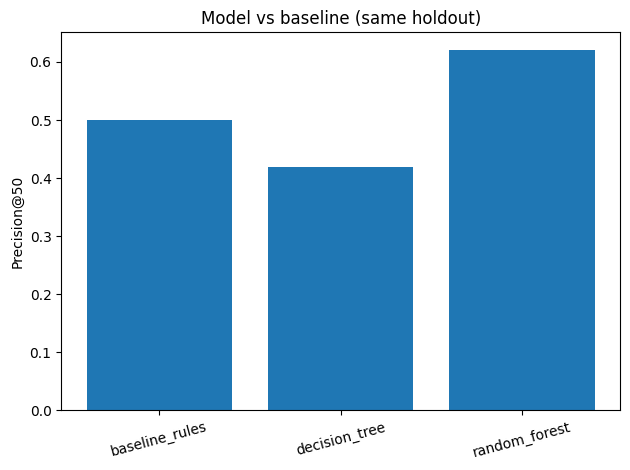

In [15]:
from pathlib import Path
import matplotlib.pyplot as plt

out = Path("work/outputs")
out.mkdir(parents=True, exist_ok=True)

results.to_csv(out / "capstone_precision_at_50.csv", index=False)
queue[show_cols].to_csv(out / "capstone_top10_queue.csv", index=False)

fig, ax = plt.subplots()
ax.bar(results["model"], results["precision_at_50"])
ax.set_ylabel("Precision@50")
ax.set_title("Model vs baseline (same holdout)")
plt.xticks(rotation=15)
fig.tight_layout()
fig.savefig(out / "capstone_precision_at_50.png", dpi=150)

print("Wrote work/outputs/capstone_precision_at_50.csv")
print("Wrote work/outputs/capstone_top10_queue.csv")
print("Wrote work/outputs/capstone_precision_at_50.png")
results

## ML-12 closing

### 5-minute demo outline
1. Problem: too many pages, no ranked refresh list
2. Method: baseline rule vs models, Precision@50, client-holdout
3. Result: baseline 0.50 > random forest 0.62 on the same split
4. Artifact: ranked queue with actions and reason codes
5. Limit: offline decision support, not causal proof

### Social-post cut
I ranked pages for content refresh on FlyRank internship data. A hand-written baseline hit 0.50 Precision@50. A random forest hit 0.62 on the same holdout. Output is a short action queue for humans, not auto-publish.

### Employer-facing summary
I built a refresh-opportunity ranking workflow on anonymized search/content signals: defined a proxy label, compared a hand-written baseline to learned models under a client-holdout split, and produced a ranked queue with reason codes. Measured Precision@50 moved from 0.50 (baseline) to 0.62 (random forest). The work is framed as decision support with explicit limits, no causal traffic claims.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
